# 0. Data Preprocessing & Feature Engineering Playground

In this notebook, we transform the raw Electricity Load Diagrams dataset into a robust format suitable for Machine Learning models.

To keep our codebase scalable and easily maintainable, the lengthy blocks of data manipulation code have been refactored into modular python tools located in the `src/tools/` directory. This notebook now serves as an **interactive playground** mapping out the logical progression of our pipeline, allowing us to test each specific step in isolation.

### Pipeline Overview:
1. **Imports & Loading**: Reading the raw file into pandas via our centralized loader.
2. **Temporal Engineering**: Extracting calendar logic rapidly before the dataset explodes in size.
3. **Physical Proxy Signals**: Scraping and calculating population-weighted degree hours.
4. **Format Reshaping**: Stacking time series from a *wide* to a *long* architecture.
5. **Client State Cleaning**: Detecting and pruning inactive periods and churned clients.
6. **Autoregressive Lags & Rolling**: Computing historical memory paths and environmental anomalies.
7. **Shape Clustering (Profiles)**: Utilizing K-Means to discover client energy usage patterns.
8. **Volume Segmentation (Jenks)**: Categorizing clients automatically by historical demand load.
9. **Export**: Serializing the final engineered state into a highly optimized Parquet format.
10. **Automation**: Orchestrating the headless production python script.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# Ensure we can seamlessly import all modular functions from the src directory
sys.path.append(os.path.abspath(".."))

# Import our specialized pipeline tools
from src.tools import add_temporal_features, get_national_weather, clean_clients, load_raw_data, apply_profile_clustering, apply_volume_clustering, add_lags_and_rolling

print("Setup complete. Environment mapped and modular tools loaded.")

✅ Setup complete. Environment mapped and modular tools loaded.


## 1. Data Loading Tracker

Raw system exports are inherently messy. Before doing any mathematical operations, we need a baseline.
Our `load_raw_data` tool handles the heavy lifting by taking the unstructured Electricity `.csv` file, converting generic strings into standard datetime formats, aggressively sorting by timestamps, and dropping any corrupt or duplicated timestamp indices.

In [79]:
# Load raw CSV data using the centralized data loader
df = load_raw_data("../Datasets/Electricity Dataset.csv")

print(f"Number of Clients tracked: {len(df.columns) - 1}")
print(f"Global Missing Values: {df.isna().sum().sum()}")

# Display first rows to verify structure
display(df.head())

Loading data from: ../Datasets/Electricity Dataset.csv...
Data loaded successfully. Shape: (140256, 371)
Number of Clients tracked: 370
Global Missing Values: 0


,Date,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
0,2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Temporal Feature Engineering

Here we calculate logical calendar variables like `Hour`, `Weekday`, `Month`, `Is_Weekend`, and dynamically shifting parameters like movable Portuguese `Holidays` (using Easter math rules).

**Crucial Optimization Logic:**
By design, we apply the `add_temporal_features` tool **before** melting the dataset. Calculating the day of the week on 140,000 distinct time rows (the current wide format) takes a fraction of a second. If we waited to execute this on the melted long format (50+ million rows), it would unnecessarily tax the CPU and take a very long time.

In [80]:
# Extract calendar features (Hour, Weekday, Month, Holidays, Weekend)
# Executed on the wide format for maximum performance optimization
df = add_temporal_features(df)

print(f"Temporal features injected. Dataset shape: {df.shape}")
display(df[['Date', 'Hour', 'Weekday', 'Is_Holiday']].head())

Temporal features injected. Dataset shape: (140256, 376)


,Date,Hour,Weekday,Is_Holiday
0,2011-01-01 00:15:00,1,6,True
1,2011-01-01 00:30:00,1,6,True
2,2011-01-01 00:45:00,1,6,True
3,2011-01-01 01:00:00,2,6,True
4,2011-01-01 01:15:00,2,6,True


## 3. Physical Proxy Signals (Population Weighted National Weather)

Because the original electricity dataset masks specific client locations to preserve privacy, we cannot map consumption to exact local weather stations.

To solve this, our `get_national_weather()` tool builds a "national average temperature" as a highly accurate proxy signal. Rather than taking a basic raw average of the 4 major Portuguese cities (Lisbon, Porto, Faro, Évora), this tool weights each city's temperature by its demographic census population.

Instead of feeding raw Celsius into the model, the tool converts temperature into the standard variables used in energy analytics—based on an $18^\circ C$ threshold:
- **HDH (Heating Degree Hours)**: Measures how many degrees the temperature is below $18^\circ C$. When high, homes activate heating systems, driving consumption spikes.
- **CDH (Cooling Degree Hours)**: Measures how many degrees the temperature is above $18^\circ C$. When high, AC units turn on, raising local load.

  Fetching weather for Lisbon...
  Fetching weather for Porto...
  Fetching weather for Faro...
  Fetching weather for Evora...
Weather coverage: 2011-01-01 00:00:00 to 2014-12-31 23:00:00
Weather NaNs: 0


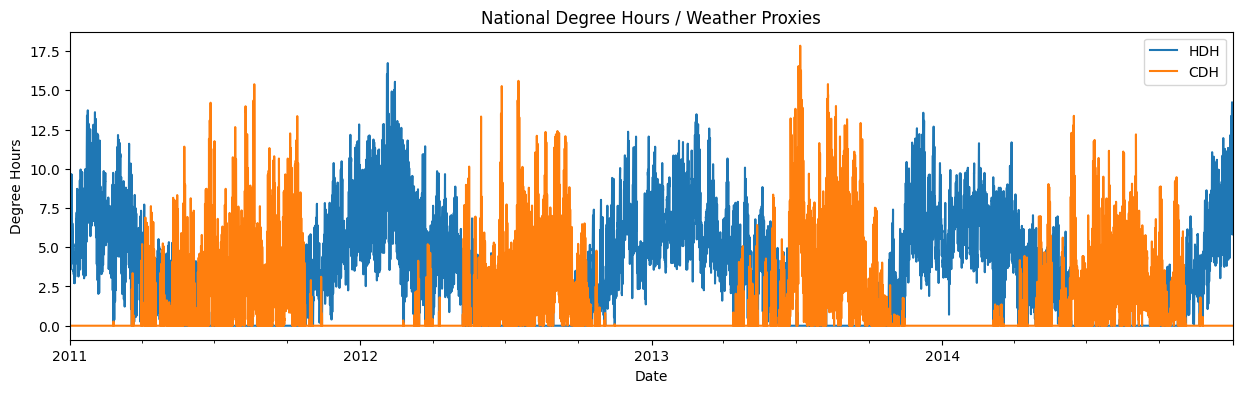

In [81]:
# Fetch weighted temperature data and derive HDH/CDH vectors (Base 18°C)
weather_df = get_national_weather(start_date="2011-01-01", end_date="2014-12-31")

print(f"Weather coverage: {weather_df['Date'].min()} to {weather_df['Date'].max()}")
print(f"Weather NaNs: {weather_df.isna().sum().sum()}")

# Sanity Check: Visualize thermal signals to verify seasonal consistency
weather_df.set_index('Date')[['HDH', 'CDH']].plot(figsize=(15, 4), title="National Degree Hours / Weather Proxies")
plt.ylabel("Degree Hours")
plt.show()

## 4. Normalization via Melting to Long Format

Machine Learning algorithms typically expect data configured as explicit "Observation x Features". Right now, our columns represent individual clients. We reshape this matrix from "wide" (370+ columns) to "long" format, stacking all client records vertically to tie every individual kW value to its respective ClientID and Datetime.

Simultaneously, we merge the external weather targets calculated in the previous step onto hourly checkpoints so standard 15-minute load readings can absorb macro weather trends.

In [82]:
print("Melting dataset to long format (stacking clients into standard ML observation rows)...")

# Defined structural columns (Time factors) to keep fixed horizontally
fixed_vars = ['Date', 'Weekday', 'Hour', 'Month', 'Is_Weekend', 'Is_Holiday']

# Transform from (Date records x Clients) to (Datetimes x Features)
df_long = pd.melt(df, id_vars=fixed_vars, var_name='ClientID', value_name='Consumption')

# Memory Optimization: Extreme casting down to keep the 50m row RAM footprint small
df_long['Consumption'] = df_long['Consumption'].astype(np.float32)
df_long['ClientID'] = df_long['ClientID'].astype('category')

# Weather Integration: Group 15-min granular bins with 1-hr weather signals
df_long['Date_Hour'] = df_long['Date'].dt.floor('h')
df_long = df_long.merge(weather_df, left_on='Date_Hour', right_on='Date', how='left', suffixes=('', '_w'))
df_long = df_long.drop(columns=['Date_Hour', 'Date_w'])

print(f"Melt complete. Stacking expanded total active rows to: {len(df_long):,}")

Melting dataset to long format (stacking clients into standard ML observation rows)...
Melt complete. Stacking expanded total active rows to: 51,894,720


## 5. Cleaning Inactive Client States

To make sure our algorithms are learning actual client behaviors and profiles—rather than hallucinating logic on dead meters—we utilize the `clean_clients()` function to trim dual types of noise:

1. **Pre-activation Nulls (Leading Zeros):** Countless clients in this dataset had their generic meters physically installed *after* 2011. This function filters out early inactive periods before a client connected to the grid formally for the first time.
2. **Churn Prevention (Inactive/Flatlined clients):** We isolate accounts who registered essentially flatlined consumption zeros within the final 30 calendar days of the historical dataset. Training a forecast on churned users heavily distorts structural ML metrics such as MAPE.

In [83]:
# Process cleanup rules to strip dead meters and unconnected timelines 
rows_before = len(df_long)
df_long = clean_clients(df_long)
rows_after = len(df_long)

print(f"Cleaning sweep complete. Total dead periods/rows removed: {rows_before - rows_after:,}")

Trimming leading zeros (finding actual start date for each client)...
Trimmed inactive periods. Remaining rows: 41936458
Removing inactive clients (near 0 consumption in the last 30 days)...
Detected 1 inactive clients in the last month.
Removed inactive clients. Remaining rows: 41796202
Cleaning sweep complete. Total dead periods/rows removed: 10,098,518


## 6. Autoregressive Lags, Rolling Contexts & Anomalies

A model cannot predict the future load effectively without internalizing the immediate, cyclical history. Using the modular `add_lags_and_rolling()` engine from our `feature_engineering` tools, we engineer specific time-shifted behavioral contexts robustly segregated by `ClientID` to prevent cross-client bleed.

This singular tool computes:
- **Short, Daily, & Weekly Lags:** Capturing direct comparisons (e.g. "*what did this exact client consume 1 step ago, yesterday, and entirely last week*?").
- **Rolling Smoothing:** Taking the 4-hour moving statistical average `Rolling_Mean_4h` to capture immediate acceleration.
- **Thermal Inertia:** Applying 24h lags to temperature inputs.
- **Weather Anomaly Tracking:** Evaluating weather deviation off a specific 30-day chronological rolling baseline.

In [84]:
# Automatically groups by ClientID ensuring chronological integrity, lag mapping, and NaN purging
print("Mapping memory vectors, building rolling windows, and calculating structural anomalies...")

df_long = add_lags_and_rolling(df_long)

print("Automated Advanced Feature Engineering Complete!")
display(df_long.head())

Mapping memory vectors, building rolling windows, and calculating structural anomalies...
Sorting data for lag calculations...
Calculating Lags...
Calculating Rolling Windows...
Dropping NaNs...
Automated Advanced Feature Engineering Complete!


,Date,Weekday,Hour,Month,Is_Weekend,Is_Holiday,ClientID,Consumption,HDH,CDH,Lag_15min,Lag_1h,Lag_24h,Lag_1week,Rolling_Mean_4h
0,2012-01-08 00:15:00,7,1,1,True,False,MT_001,5.076142,8.141814,0.0,5.076142,19.035534,3.807106,3.807106,14.118020
1,2012-01-08 00:30:00,7,1,1,True,False,MT_001,5.076142,8.141814,0.0,5.076142,16.497461,3.807106,5.076142,13.324873
2,2012-01-08 00:45:00,7,1,1,True,False,MT_001,5.076142,8.141814,0.0,5.076142,5.076142,5.076142,3.807106,12.531726
3,2012-01-08 01:00:00,7,2,1,True,False,MT_001,5.076142,8.602323,0.0,5.076142,5.076142,3.807106,3.807106,11.579949
4,2012-01-08 01:15:00,7,2,1,True,False,MT_001,3.807106,8.602323,0.0,5.076142,5.076142,3.807106,5.076142,10.786802


## 7. Shape Clustering Exploration (Elbow Method)

Electricity isn't just about total volume; *when* a client consumes power defines their unique profile (e.g., night-time peaks vs standard business hours). We use **K-Means Clustering** strictly on the Training set (data before 2014 to avoid data leakage) to discover abstract consumption shapes.

First, we plot the **Elbow Method** to heuristically determine the optimal number of clusters (`k`).

Isolating training data (before 2014) to prevent data leakage...
Creating average hourly dimensional profiles...
Normalizing profiles using transpose logic...
Calculating inertia for K-Means Elbow Method...


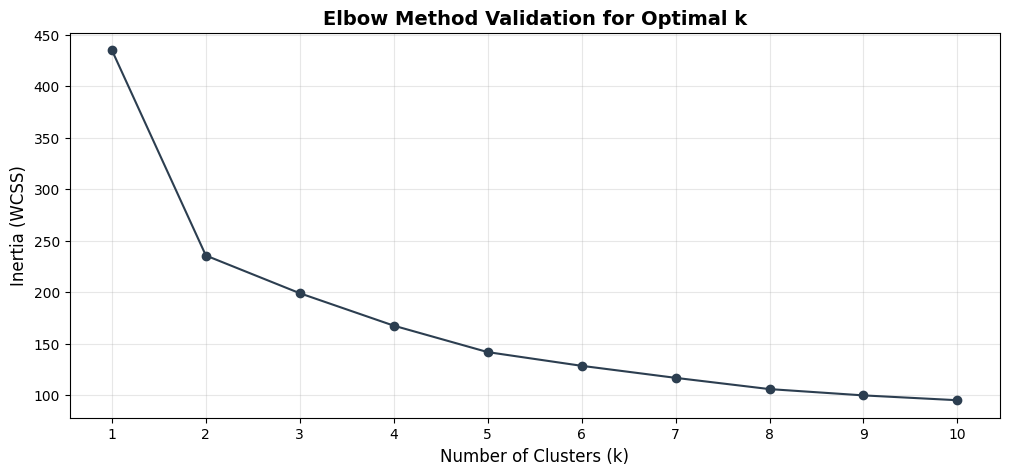

In [ ]:
print("Isolating training data (before 2014) to prevent data leakage...")
df_train = df_long[df_long['Date'].dt.year < 2014]

print("Creating average hourly dimensional profiles...")
profiles = df_train.groupby(['ClientID', 'Hour'], observed=True)['Consumption'].mean().unstack().fillna(0)

print("Normalizing profiles using transpose logic...")
scaler = MinMaxScaler()
profiles_scaled = scaler.fit_transform(profiles.T).T

inertia = []
K_range = range(1, 11)

print("Calculating inertia for K-Means Elbow Method...")
for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(profiles_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(12, 5))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='#2c3e50')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.title('Elbow Method Validation for Optimal k', fontsize=14, fontweight='bold')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

## 8. Rendering & Integrating Load Profiles

Observing the Elbow plot, $k=5$ provides a strong balance. Instead of manually re-writing the clustering and Matplotlib code, we execute the unified `apply_profile_clustering()` tool on our dataset. By parsing `plot=True`, this single line not only fits the model and tags all rows with a `Cluster` attribute, but also visually outputs the 5 normalized consumption curves instantly!

Injecting Shape Clustering via modular tool...
Calculating shape clusters (k=5) based on Training data...
Executing final K-Means with k=5 clusters...


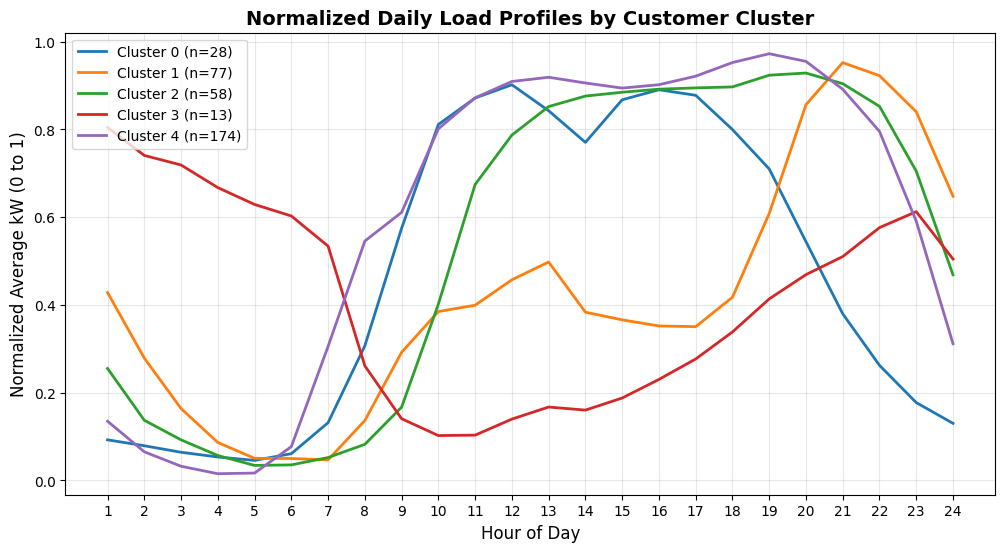

Shape clusters mapped successfully!


In [ ]:
print("Injecting Shape Clustering via modular tool...")
df_train = df_long[df_long['Date'].dt.year < 2014].copy()
df_test  = df_long[df_long['Date'].dt.year >= 2014].copy()

# Setting plot=True natively renders the profile charts!
df_train, df_test = apply_profile_clustering(df_train, df_test, n_clusters=5, plot=True)

df_long = pd.concat([df_train, df_test]).sort_values(by=['ClientID', 'Date']).reset_index(drop=True)
print("Shape clusters mapped successfully!")

## 9. Volume Segmentation via Fisher-Jenks Natural Breaks

While clustering isolated the *shape* of consumption, we must also categorize clients by sheer *volume* (Heavy vs Light). Electricity volumes are highly skewed, so standard bins fail.

Again, we hide the heavy Python math and visual rendering syntax inside a single tool call: `apply_volume_clustering()`. Because we passed `plot=True`, it automatically executes `np.log1p` normalization, tracks the Jenks limits, tags `df_long` with `Consumer_Category` and effortlessly graphs the segmented histogram mapping out 'Light', 'Medium', and 'Heavy' profiles.

Injecting Volume Categorization via modular tool...
Calculating volume categorizations (Light, Medium, Heavy)...
Jenks Breakpoints Detected:
 > Light consumers:  below 62.79 kW average
 > Medium consumers: 62.79 to 392.05 kW average
 > Heavy consumers:  above 392.05 kW average


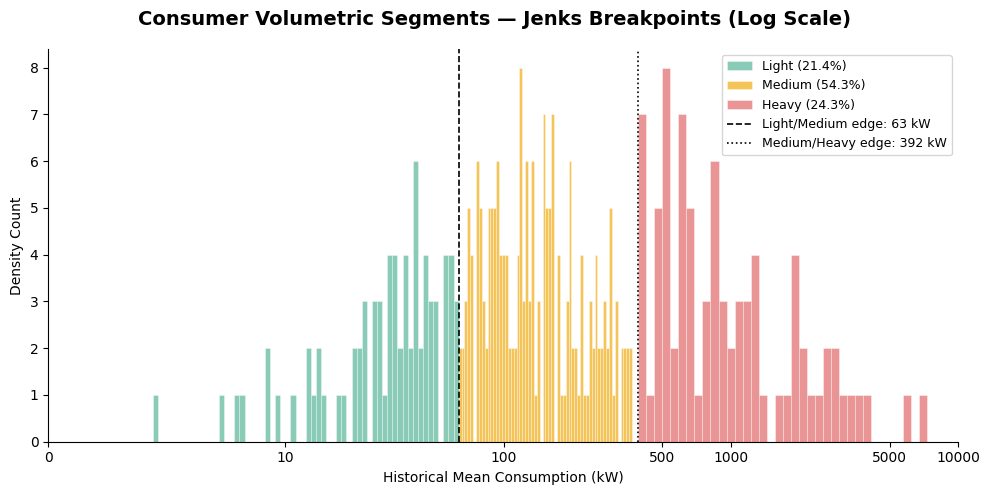

Volume categories mapped successfully!


,ClientID,Date,Consumption,Cluster,Consumer_Category
0,MT_001,2012-01-08 00:15:00,5.076142,1.0,Light
1,MT_001,2012-01-08 00:30:00,5.076142,1.0,Light
2,MT_001,2012-01-08 00:45:00,5.076142,1.0,Light
3,MT_001,2012-01-08 01:00:00,5.076142,1.0,Light
4,MT_001,2012-01-08 01:15:00,3.807106,1.0,Light


In [ ]:
print("Injecting Volume Categorization via modular tool...")
df_train = df_long[df_long['Date'].dt.year < 2014].copy()
df_test  = df_long[df_long['Date'].dt.year >= 2014].copy()

# Setting plot=True natively executes Jenks and outputs the distribution chart!
df_train, df_test = apply_volume_clustering(df_train, df_test, plot=True)

df_long = pd.concat([df_train, df_test]).sort_values(by=['ClientID', 'Date']).reset_index(drop=True)
print("Volume categories mapped successfully!")
display(df_long[['ClientID', 'Date', 'Consumption', 'Cluster', 'Consumer_Category']].head())

## 10. Total Automation Execution Context

By running `process_data.py`, this entire operation happens headless through our orchestrator pipeline to yield the identical `.parquet` state.

In [89]:
# Triggering the unified orchestrator script automatically.
!python ../process_data.py

Loading data...
Loading data from: /Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-electricity/notebooks/../Datasets/Electricity Dataset.csv...
Data loaded successfully. Shape: (140256, 371)
Adding temporal features...
Melting...
Trimming leading zeros (finding actual start date for each client)...
Trimmed inactive periods. Remaining rows: 41936458
Removing inactive clients (near 0 consumption in the last 30 days)...
Detected 1 inactive clients in the last month.
Removed inactive clients. Remaining rows: 41796202
Fetching and merging weather...
  Fetching weather for Lisbon...
  Fetching weather for Porto...
  Fetching weather for Faro...
  Fetching weather for Evora...
Sorting data for lag calculations...
Checking for missing timestamps...
Calculating Lags...
Calculating weather lags (thermal inertia)...
Calculating weather anomalies (30-day rolling baseline)...
Calculating Rolling Windows...
Dropping NaNs...
Applying Shape & Volume clustering